In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

def model_violin_plot(filepath: str, model: str, plotpath: str = None):
    df = pd.read_parquet(filepath)
    df = df[df["model_name"] == model]

    if df.empty:
        raise ValueError(f"No data found for model: {model}")

    score_cols = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
    available_cols = [c for c in score_cols if c in df.columns and df[c].notna().any()]

    if not available_cols:
        raise ValueError(f"No valid score columns found for model: {model}")

    # Melt to long form
    long_df = df[available_cols].melt(var_name="Dimension", value_name="Score").dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(data=long_df, x="Dimension", y="Score", ax=ax, inner="box")
    ax.set_title(f"Score Distribution — {model}")
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Score")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300)
        print(f"Plot saved to: {plotpath}")

    plt.show()

model_violin_plot("./data/out/videos.parquet", "llama-3b-inst-4bit", plotpath="./plots/violin_llama-3b-inst-4bit.png")

KeyError: 'model_name'

In [ ]:
import pandas as pd
df = pd.read_parquet("./data/out/videos.parquet")
print(df.columns.tolist())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MODELS = ["llama-3b-inst-4bit", "mistral-3-14b-inst-4bit", "ministral-3-14b"]
PROMPT_VARIANTS = ["full", "anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
DIMENSIONS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]

def model_violin_plot(filepath: str, model: str, plotpath: str = None):
    df = pd.read_parquet(filepath)

    # Collect all columns for this model: {model}_{prompt_variant}_{dimension}
    records = []
    for variant in PROMPT_VARIANTS:
        for dim in DIMENSIONS:
            col = f"{model}_{variant}_{dim}"
            if col in df.columns:
                tmp = df[[col]].dropna().copy()
                tmp["prompt_variant"] = variant
                tmp["dimension"] = dim
                tmp["score"] = tmp[col]
                records.append(tmp[["prompt_variant", "dimension", "score"]])

    if not records:
        raise ValueError(f"No columns found for model: {model}")

    long_df = pd.concat(records, ignore_index=True)

    # One subplot per prompt variant
    variants_present = long_df["prompt_variant"].unique()
    fig, axes = plt.subplots(1, len(variants_present), figsize=(4 * len(variants_present), 6), sharey=True)
    if len(variants_present) == 1:
        axes = [axes]

    for ax, variant in zip(axes, variants_present):
        data = long_df[long_df["prompt_variant"] == variant]
        sns.violinplot(data=data, x="dimension", y="score", ax=ax, inner="box")
        ax.set_title(variant)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle(f"Score Distribution — {model}", fontsize=14)
    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {plotpath}")

    plt.show()

model_violin_plot("./data/out/videos.parquet", "llama-3b-inst-4bit", plotpath="./plots/violin_llama-3b-inst-4bit.png")

Plot saved to: ./plots/violin_llama-3b-inst-4bit.png


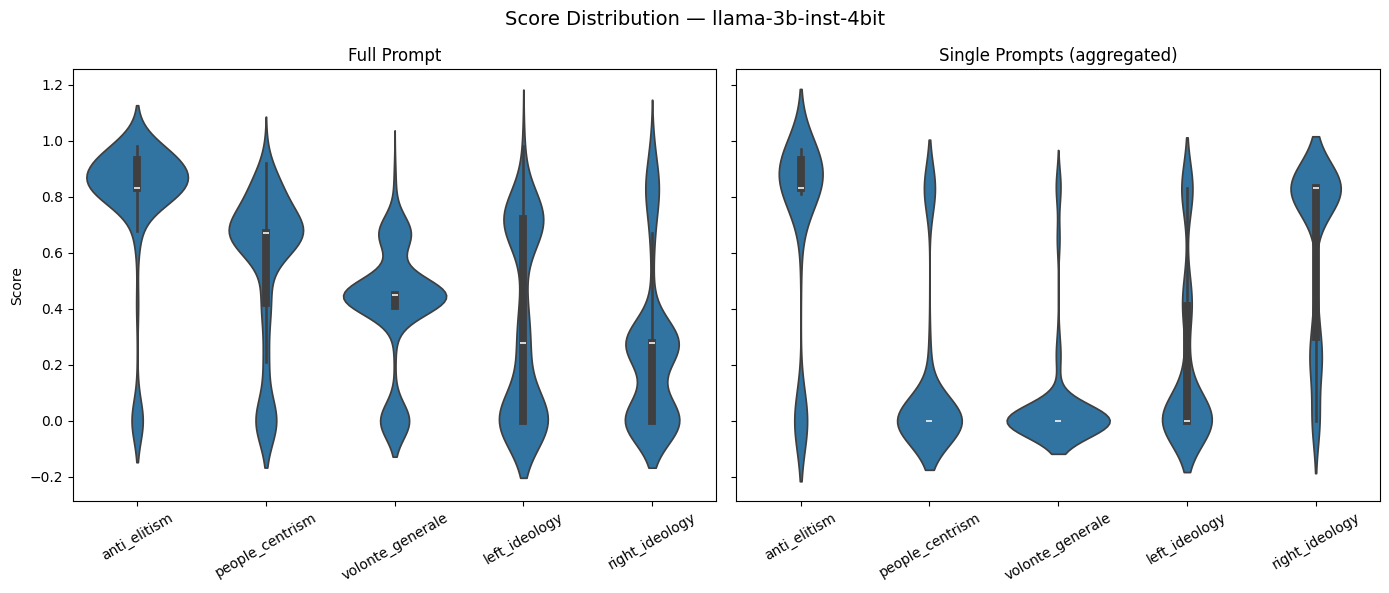

Plot saved to: ./plots/violin_llama-3b-inst-4bit.png


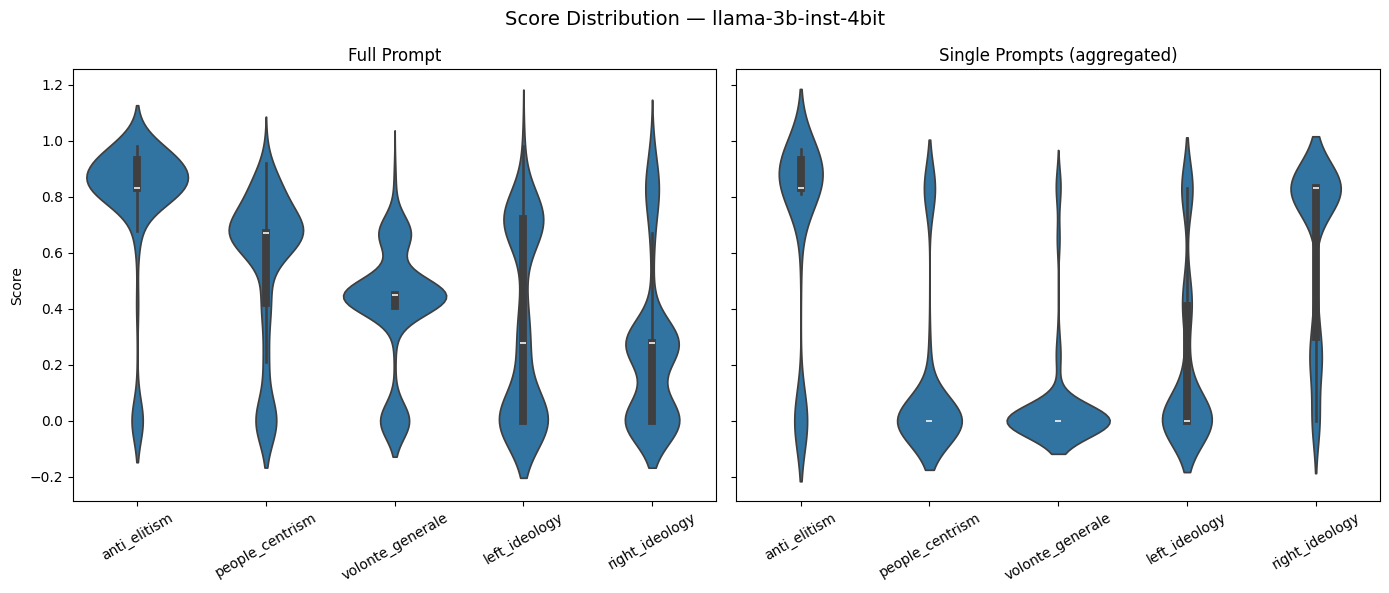

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DIMENSIONS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
SINGLE_VARIANTS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]

def model_violin_plot(filepath: str, model: str, plotpath: str = None):
    df = pd.read_parquet(filepath)

    # --- Full prompt variant ---
    full_records = []
    for dim in DIMENSIONS:
        col = f"{model}_full_{dim}"
        if col in df.columns:
            tmp = df[[col]].dropna().rename(columns={col: "score"})
            tmp["dimension"] = dim
            full_records.append(tmp)

    # --- Single prompt variants (aggregated) ---
    single_records = []
    for variant in SINGLE_VARIANTS:
        for dim in DIMENSIONS:
            col = f"{model}_{variant}_{dim}"
            if col in df.columns:
                tmp = df[[col]].dropna().rename(columns={col: "score"})
                tmp["dimension"] = dim
                single_records.append(tmp)

    if not full_records and not single_records:
        raise ValueError(f"No columns found for model: {model}")

    full_df = pd.concat(full_records, ignore_index=True)
    single_df = pd.concat(single_records, ignore_index=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    sns.violinplot(data=full_df, x="dimension", y="score", ax=ax1, inner="box")
    ax1.set_title("Full Prompt")
    ax1.set_xlabel("")
    ax1.set_ylabel("Score")
    ax1.tick_params(axis="x", rotation=30)

    sns.violinplot(data=single_df, x="dimension", y="score", ax=ax2, inner="box")
    ax2.set_title("Single Prompts (aggregated)")
    ax2.set_xlabel("")
    ax2.set_ylabel("")
    ax2.tick_params(axis="x", rotation=30)

    fig.suptitle(f"Score Distribution — {model}", fontsize=14)
    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {plotpath}")

    plt.show()

model_violin_plot("./data/out/videos.parquet", "llama-3b-inst-4bit", plotpath="./plots/violin_llama-3b-inst-4bit.png")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DIMENSIONS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
SINGLE_VARIANTS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]

def model_violin_plot(filepath: str, model: str, plotpath: str = None):
    df = pd.read_parquet(filepath)

    # --- Full prompt variant ---
    full_records = []
    for dim in DIMENSIONS:
        col = f"{model}_full_{dim}"
        if col in df.columns:
            tmp = df[[col]].dropna().rename(columns={col: "score"})
            tmp["dimension"] = dim
            full_records.append(tmp)

    # --- Single prompt variants (aggregated) ---
    single_records = []
    for variant in SINGLE_VARIANTS:
        for dim in DIMENSIONS:
            col = f"{model}_{variant}_{dim}"
            if col in df.columns:
                tmp = df[[col]].dropna().rename(columns={col: "score"})
                tmp["dimension"] = dim
                single_records.append(tmp)

    if not full_records and not single_records:
        raise ValueError(f"No columns found for model: {model}")

    full_df = pd.concat(full_records, ignore_index=True)
    single_df = pd.concat(single_records, ignore_index=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    sns.violinplot(data=full_df, x="dimension", y="score", ax=ax1, inner="box")
    ax1.set_title("Full Prompt")
    ax1.set_xlabel("")
    ax1.set_ylabel("Score")
    ax1.tick_params(axis="x", rotation=30)

    sns.violinplot(data=single_df, x="dimension", y="score", ax=ax2, inner="box")
    ax2.set_title("Single Prompts (aggregated)")
    ax2.set_xlabel("")
    ax2.set_ylabel("")
    ax2.tick_params(axis="x", rotation=30)

    fig.suptitle(f"Score Distribution — {model}", fontsize=14)
    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {plotpath}")

    plt.show()

model_violin_plot("./data/out/videos.parquet", "llama-3b-inst-4bit", plotpath="./plots/violin_llama-3b-inst-4bit.png")

Plot saved to: ./plots/violin_llama-3b-inst-4bit.png


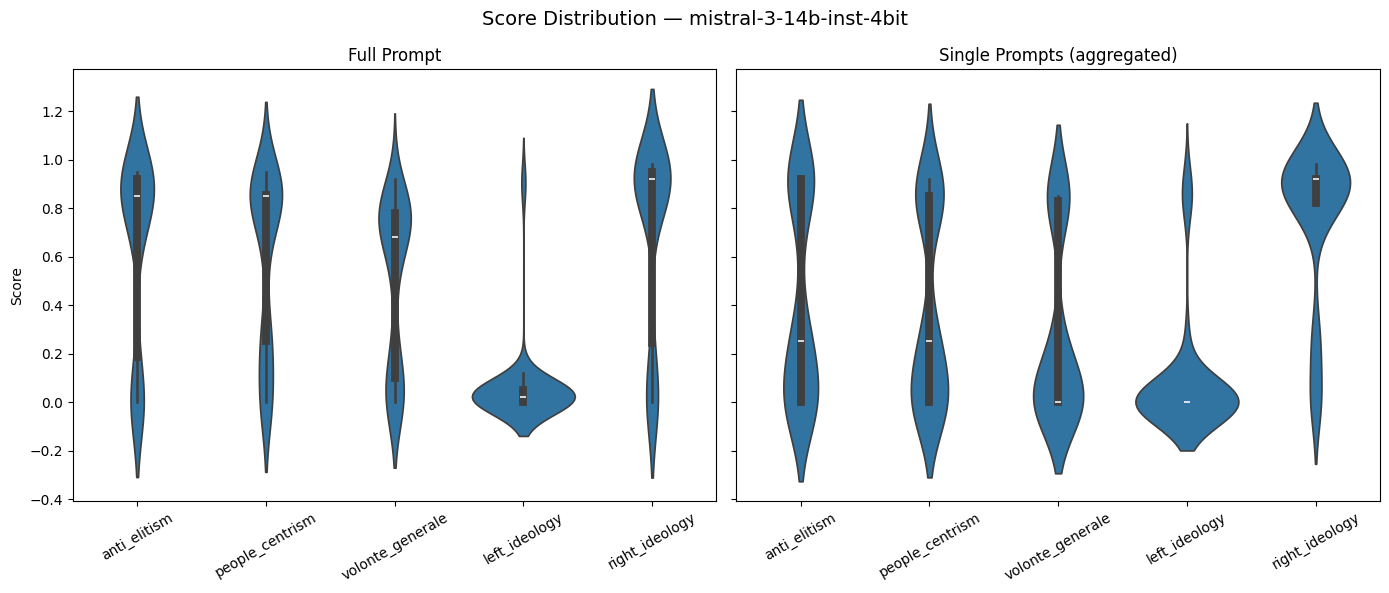

In [4]:

model_violin_plot("./data/out/videos.parquet", "mistral-3-14b-inst-4bit", plotpath="./plots/violin_llama-3b-inst-4bit.png")

/var/folders/6n/qbkx86t95c99jm_0m0p5yn7m0000gn/T/ipykernel_32927/508986180.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.replace("_", " ") for d in DIMENSIONS], ha="right")
/var/folders/6n/qbkx86t95c99jm_0m0p5yn7m0000gn/T/ipykernel_32927/508986180.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.replace("_", " ") for d in DIMENSIONS], ha="right")


Plot saved to: ./plots/violin_llama-3b-inst-4bit.png


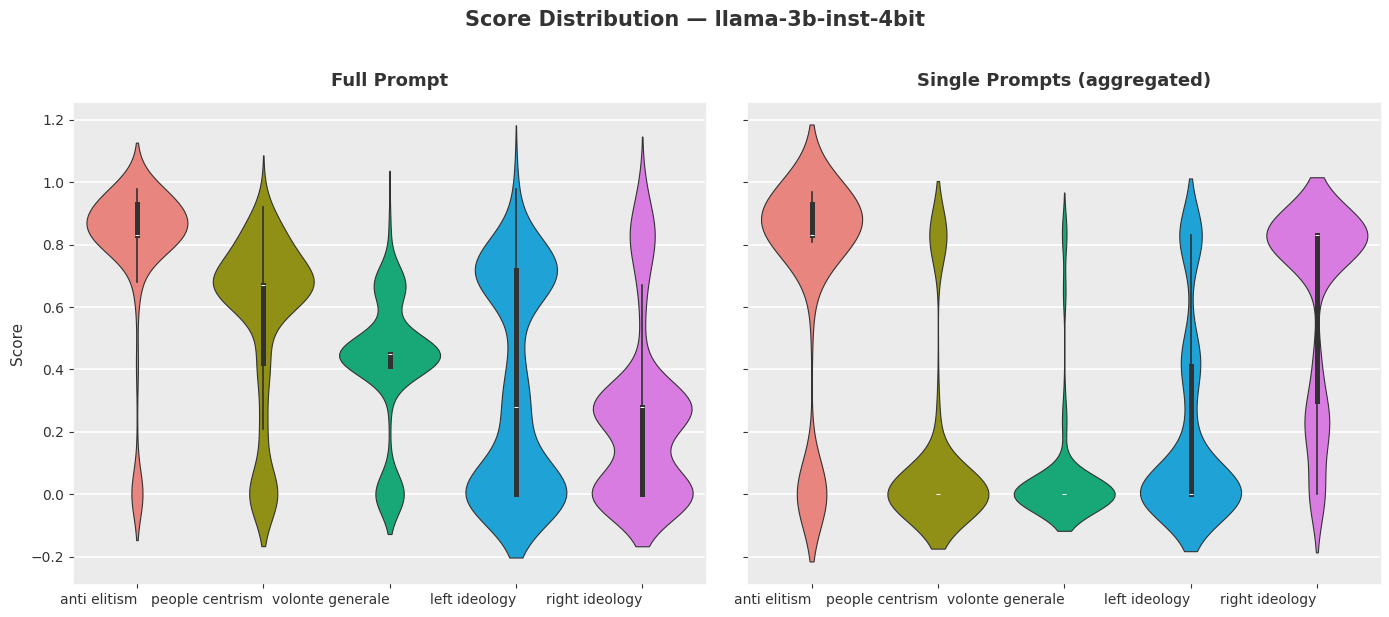

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

DIMENSIONS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
SINGLE_VARIANTS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]

def model_violin_plot(filepath: str, model: str, plotpath: str = None):
    df = pd.read_parquet(filepath)

    # --- Full prompt variant ---
    full_records = []
    for dim in DIMENSIONS:
        col = f"{model}_full_{dim}"
        if col in df.columns:
            tmp = df[[col]].dropna().rename(columns={col: "score"})
            tmp["dimension"] = dim
            full_records.append(tmp)

    # --- Single prompt variants (aggregated) ---
    single_records = []
    for variant in SINGLE_VARIANTS:
        for dim in DIMENSIONS:
            col = f"{model}_{variant}_{dim}"
            if col in df.columns:
                tmp = df[[col]].dropna().rename(columns={col: "score"})
                tmp["dimension"] = dim
                single_records.append(tmp)

    if not full_records and not single_records:
        raise ValueError(f"No columns found for model: {model}")

    full_df = pd.concat(full_records, ignore_index=True)
    single_df = pd.concat(single_records, ignore_index=True)

    # ggplot2 style
    plt.style.use("ggplot")
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "axes.facecolor": "#EBEBEB",
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.color": "white",
        "grid.linewidth": 1.2,
        "axes.edgecolor": "#EBEBEB",
        "axes.labelcolor": "#333333",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "text.color": "#333333",
    })

    ggplot_palette = ["#F8766D", "#A3A500", "#00BF7D", "#00B0F6", "#E76BF3"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    for ax, data, title in [
        (ax1, full_df, "Full Prompt"),
        (ax2, single_df, "Single Prompts (aggregated)"),
    ]:
        sns.violinplot(
            data=data,
            x="dimension",
            y="score",
            ax=ax,
            inner="box",
            hue="dimension",
            palette=ggplot_palette,
            legend=False,
            linewidth=0.8,
        )
        ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("", fontsize=11)
        ax.set_ylabel("Score" if ax == ax1 else "", fontsize=11)
        ax.set_xticklabels([d.replace("_", " ") for d in DIMENSIONS], ha="right")

    fig.suptitle(f"Score Distribution — {model}", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {plotpath}")

    plt.show()

model_violin_plot("./data/out/videos.parquet", "llama-3b-inst-4bit", plotpath="./plots/violin_llama-3b-inst-4bit.png")

Plot saved to: ./plots/violin_llama-3b-inst-4bit.png


/var/folders/6n/qbkx86t95c99jm_0m0p5yn7m0000gn/T/ipykernel_32927/508986180.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.replace("_", " ") for d in DIMENSIONS], ha="right")
/var/folders/6n/qbkx86t95c99jm_0m0p5yn7m0000gn/T/ipykernel_32927/508986180.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.replace("_", " ") for d in DIMENSIONS], ha="right")


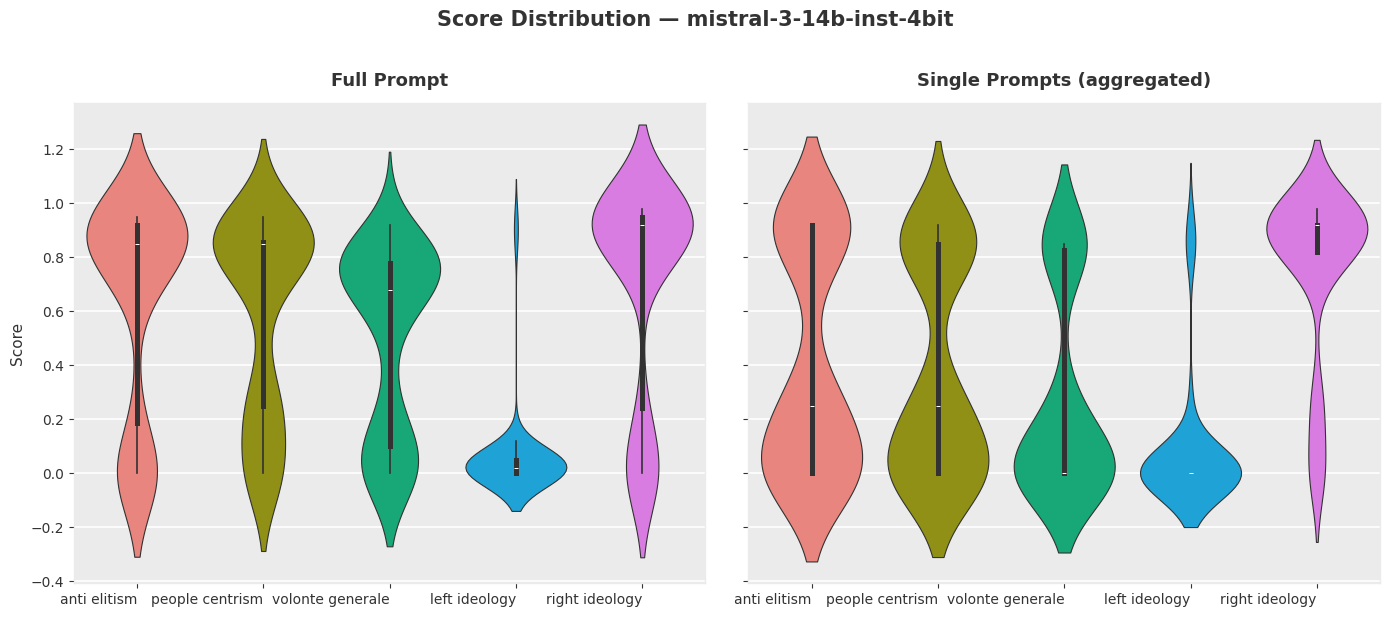

In [6]:

model_violin_plot("./data/out/videos.parquet", "mistral-3-14b-inst-4bit", plotpath="./plots/violin_llama-3b-inst-4bit.png")

# Bert Output

Plot saved to: ./plots/violin_bert.png


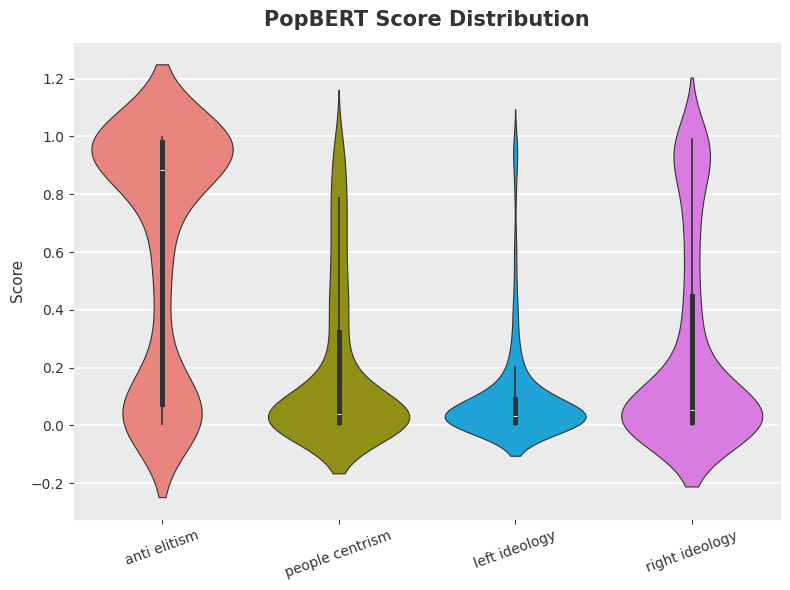

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import ast

BERT_DIMS = ["anti_elitism", "people_centrism", "left_ideology", "right_ideology"]

def bert_violin_plot(filepath: str, plotpath: str = None):
    df = pd.read_parquet(filepath)

    def parse_tensor(val):
        if pd.isna(val):
            return None
        try:
            return ast.literal_eval(str(val))
        except:
            return None

    parsed = df["bert_output"].apply(parse_tensor).dropna()
    arr = np.array(parsed.tolist())  # shape (n, 4)

    records = []
    for i, dim in enumerate(BERT_DIMS):
        for val in arr[:, i]:
            records.append({"dimension": dim.replace("_", " "), "score": val})

    long_df = pd.DataFrame(records)

    plt.style.use("ggplot")
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "axes.facecolor": "#EBEBEB",
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.color": "white",
        "grid.linewidth": 1.2,
        "axes.edgecolor": "#EBEBEB",
        "axes.labelcolor": "#333333",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "text.color": "#333333",
    })

    ggplot_palette = ["#F8766D", "#A3A500", "#00B0F6", "#E76BF3"]

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.violinplot(
        data=long_df,
        x="dimension",
        y="score",
        ax=ax,
        inner="box",
        hue="dimension",
        palette=ggplot_palette,
        legend=False,
        linewidth=0.8,
    )

    ax.set_title("PopBERT Score Distribution", fontsize=15, fontweight="bold", pad=12)
    ax.set_xlabel("", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {plotpath}")

    plt.show()

bert_violin_plot("./data/out/videos.parquet", plotpath="./plots/violin_bert.png")

Plot saved to: ./plots/corr_bert_llama.png


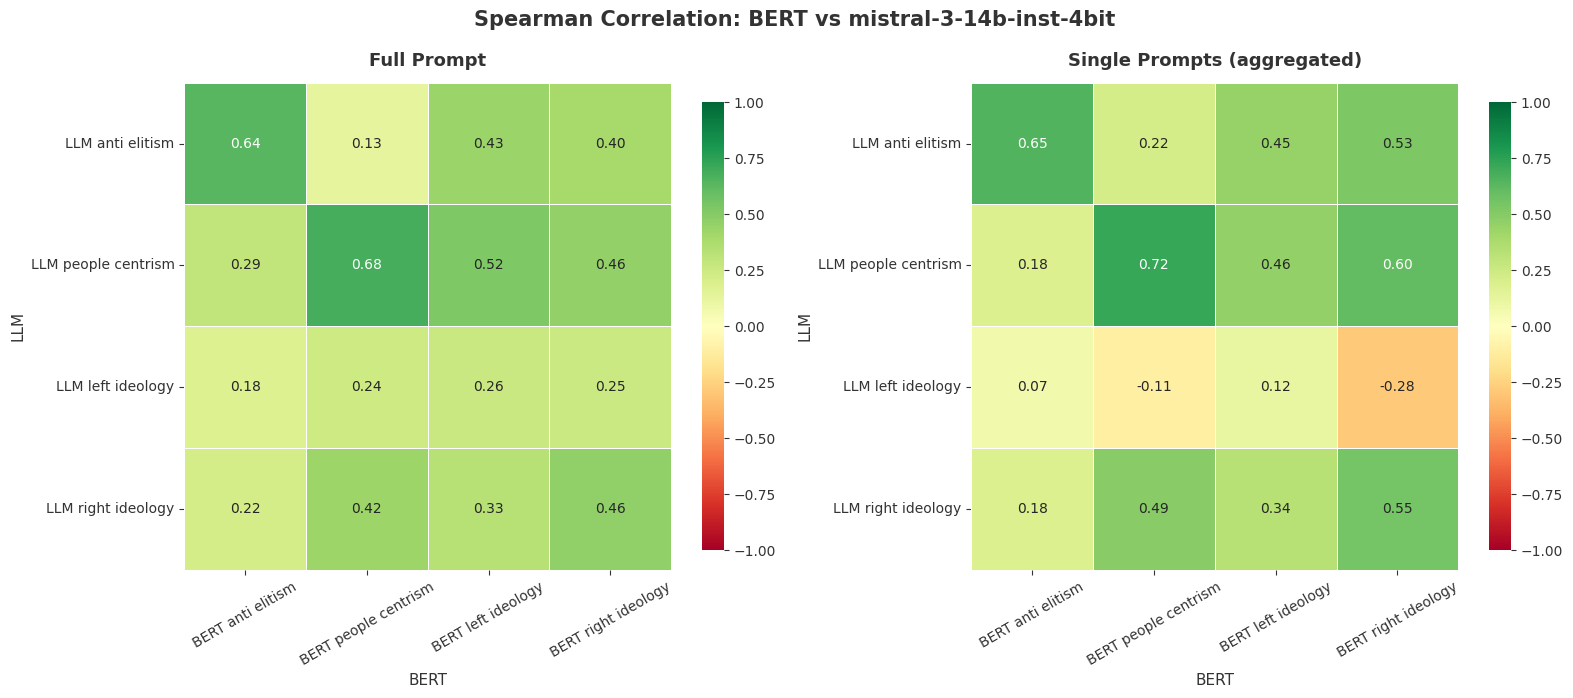

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import ast

BERT_DIMS = ["anti_elitism", "people_centrism", "left_ideology", "right_ideology"]
SINGLE_VARIANTS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
MODEL = "mistral-3-14b-inst-4bit"

def parse_tensor(val):
    if pd.isna(val):
        return None
    try:
        return ast.literal_eval(str(val))
    except:
        return None

def build_corr_matrix(df, variant):
    """Build correlation matrix between BERT and LLM scores for a given prompt variant."""
    rows = {}

    # BERT columns
    parsed = df["bert_output"].apply(parse_tensor).dropna()
    bert_arr = np.array(parsed.tolist())
    for i, dim in enumerate(BERT_DIMS):
        rows[f"BERT {dim.replace('_', ' ')}"] = pd.Series(bert_arr[:, i], index=parsed.index)

    # LLM columns for given variant
    for dim in BERT_DIMS:  # only shared dims
        col = f"{MODEL}_{variant}_{dim}"
        if col in df.columns:
            rows[f"LLM {dim.replace('_', ' ')}"] = df[col]

    combined = pd.DataFrame(rows).dropna()
    return combined.corr(method="spearman")

def correlation_heatmap(filepath: str, plotpath: str = None):
    df = pd.read_parquet(filepath)

    # ggplot2 style
    plt.style.use("ggplot")
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "axes.facecolor": "#EBEBEB",
        "figure.facecolor": "white",
        "axes.grid": False,
        "axes.labelcolor": "#333333",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "text.color": "#333333",
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    for ax, variant, title in [
        (ax1, "full", "Full Prompt"),
        (ax2, "aggregated", "Single Prompts (aggregated)"),
    ]:
        if variant == "aggregated":
            # Average across all single variant columns per dimension
            df_agg = df.copy()
            for dim in BERT_DIMS:
                cols = [f"{MODEL}_{v}_{dim}" for v in SINGLE_VARIANTS if f"{MODEL}_{v}_{dim}" in df.columns]
                df_agg[f"agg_{dim}"] = df_agg[cols].mean(axis=1)

            rows = {}
            parsed = df_agg["bert_output"].apply(parse_tensor).dropna()
            bert_arr = np.array(parsed.tolist())
            for i, dim in enumerate(BERT_DIMS):
                rows[f"BERT {dim.replace('_', ' ')}"] = pd.Series(bert_arr[:, i], index=parsed.index)
            for dim in BERT_DIMS:
                rows[f"LLM {dim.replace('_', ' ')}"] = df_agg[f"agg_{dim}"]
            corr = pd.DataFrame(rows).dropna().corr(method="spearman")
        else:
            corr = build_corr_matrix(df, variant)

        # Only show BERT vs LLM quadrant
        bert_cols = [c for c in corr.columns if c.startswith("BERT")]
        llm_cols  = [c for c in corr.columns if c.startswith("LLM")]
        quadrant  = corr.loc[llm_cols, bert_cols]

        sns.heatmap(
            quadrant,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor="white",
            square=True,
            cbar_kws={"shrink": 0.8},
        )
        ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("BERT", fontsize=11)
        ax.set_ylabel("LLM", fontsize=11)
        ax.tick_params(axis="x", rotation=30)
        ax.tick_params(axis="y", rotation=0)

    fig.suptitle(f"Spearman Correlation: BERT vs {MODEL}", fontsize=15, fontweight="bold")
    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {plotpath}")

    plt.show()

correlation_heatmap("./data/out/videos.parquet", plotpath="./plots/corr_bert_llama.png")

Plot saved to: ./plots/reliability_bert_llama.png


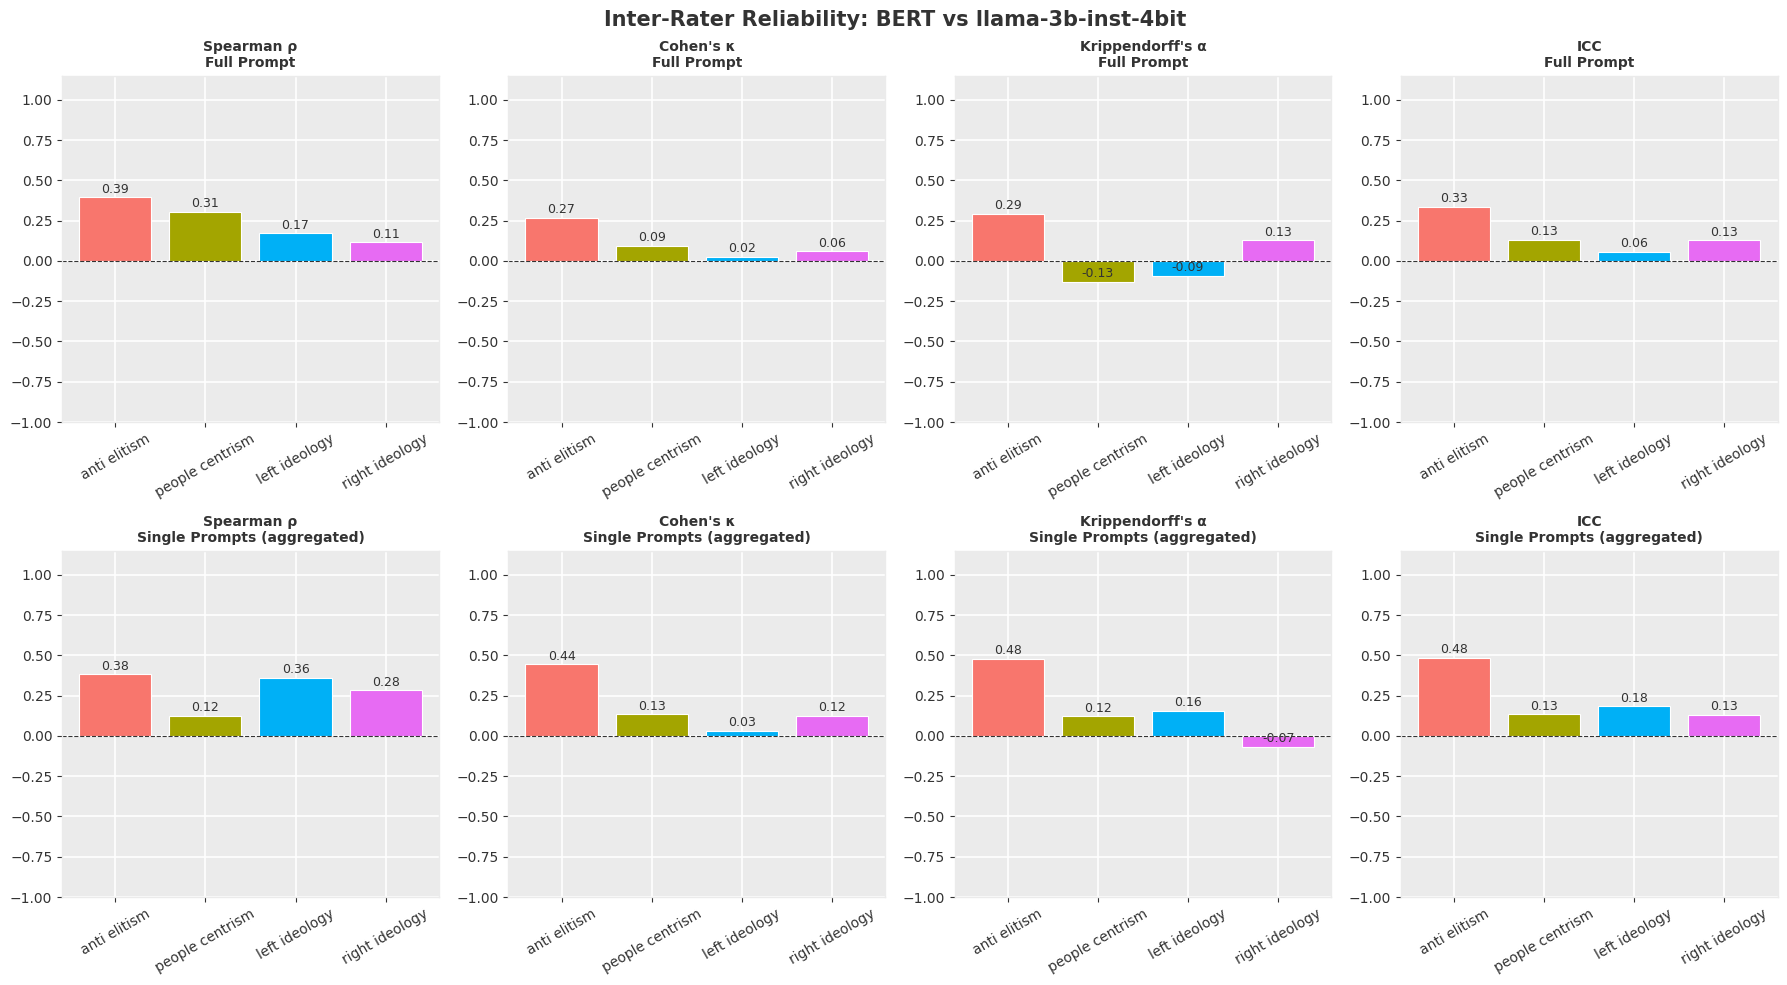

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import ast
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from pingouin import intraclass_corr
import krippendorff

BERT_DIMS = ["anti_elitism", "people_centrism", "left_ideology", "right_ideology"]
SINGLE_VARIANTS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
MODEL = "llama-3b-inst-4bit"
THRESHOLD = 0.5

def parse_tensor(val):
    if pd.isna(val):
        return None
    try:
        return ast.literal_eval(str(val))
    except:
        return None

def get_bert_series(df):
    parsed = df["bert_output"].apply(parse_tensor).dropna()
    arr = np.array(parsed.tolist())
    return {dim: pd.Series(arr[:, i], index=parsed.index) for i, dim in enumerate(BERT_DIMS)}

def get_llm_series(df, variant):
    if variant == "aggregated":
        result = {}
        for dim in BERT_DIMS:
            cols = [f"{MODEL}_{v}_{dim}" for v in SINGLE_VARIANTS if f"{MODEL}_{v}_{dim}" in df.columns]
            result[dim] = df[cols].mean(axis=1)
        return result
    else:
        return {dim: df.get(f"{MODEL}_{variant}_{dim}") for dim in BERT_DIMS}

def compute_metrics(bert_s, llm_s):
    combined = pd.DataFrame({"bert": bert_s, "llm": llm_s}).dropna()
    b, l = combined["bert"], combined["llm"]

    # Spearman
    spearman_r, spearman_p = stats.spearmanr(b, l)

    # Cohen's Kappa (binarized)
    b_bin = (b >= THRESHOLD).astype(int)
    l_bin = (l >= THRESHOLD).astype(int)
    kappa = cohen_kappa_score(b_bin, l_bin)

    # Krippendorff's Alpha (continuous)
    alpha = krippendorff.alpha(
        reliability_data=np.array([b.values, l.values]),
        level_of_measurement="interval"
    )

    # ICC
    icc_df = pd.DataFrame({
        "targets": list(range(len(combined))) * 2,
        "raters": ["bert"] * len(combined) + ["llm"] * len(combined),
        "scores": list(b.values) + list(l.values),
    })
    icc_result = intraclass_corr(data=icc_df, targets="targets", raters="raters", ratings="scores")
    icc = icc_result[icc_result["Type"] == "ICC2"]["ICC"].values[0]

    return {"spearman": spearman_r, "kappa": kappa, "krippendorff": alpha, "icc": icc}

def plot_metrics(filepath: str, plotpath: str = None):
    df = pd.read_parquet(filepath)
    bert = get_bert_series(df)

    plt.style.use("ggplot")
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "axes.facecolor": "#EBEBEB",
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.color": "white",
        "grid.linewidth": 1.2,
        "axes.edgecolor": "#EBEBEB",
        "axes.labelcolor": "#333333",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "text.color": "#333333",
    })

    metrics = ["spearman", "kappa", "krippendorff", "icc"]
    metric_labels = ["Spearman ρ", "Cohen's κ", "Krippendorff's α", "ICC"]
    variants = ["full", "aggregated"]
    variant_labels = {"full": "Full Prompt", "aggregated": "Single Prompts (aggregated)"}

    fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=False)

    ggplot_palette = ["#F8766D", "#A3A500", "#00B0F6", "#E76BF3"]

    for row, variant in enumerate(variants):
        llm = get_llm_series(df, variant)

        results = {dim: compute_metrics(bert[dim], llm[dim]) for dim in BERT_DIMS}
        results_df = pd.DataFrame(results).T  # dims x metrics

        for col, (metric, label) in enumerate(zip(metrics, metric_labels)):
            ax = axes[row, col]
            values = results_df[metric]
            bars = ax.bar(
                [d.replace("_", " ") for d in BERT_DIMS],
                values,
                color=ggplot_palette,
                edgecolor="white",
                linewidth=0.8,
            )
            # Annotate values
            for bar, val in zip(bars, values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{val:.2f}",
                    ha="center", va="bottom", fontsize=9, color="#333333"
                )
            ax.set_title(f"{label}\n{variant_labels[variant]}", fontsize=10, fontweight="bold")
            ax.set_ylim(-1, 1.15)
            ax.axhline(0, color="#333333", linewidth=0.8, linestyle="--")
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=30)

    fig.suptitle(f"Inter-Rater Reliability: BERT vs {MODEL}", fontsize=15, fontweight="bold")
    plt.tight_layout()

    if plotpath:
        plt.savefig(plotpath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {plotpath}")

    plt.show()

plot_metrics("./data/out/videos.parquet", plotpath="./plots/reliability_bert_llama.png")

In [35]:
results_rows = []
for variant in ["full", "aggregated"]:
    llm = get_llm_series(df, variant)
    for dim in BERT_DIMS:
        m = compute_metrics(bert[dim], llm[dim])
        results_rows.append({
            "variant": variant,
            "dimension": dim,
            **m
        })

results_table = pd.DataFrame(results_rows)
results_table.columns = ["Variant", "Dimension", "Spearman ρ", "Cohen's κ", "Krippendorff's α", "ICC"]
print(results_table.to_string(index=False))

NameError: name 'bert' is not defined

In [36]:
import pandas as pd
import numpy as np
import ast
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from pingouin import intraclass_corr
import krippendorff

BERT_DIMS = ["anti_elitism", "people_centrism", "left_ideology", "right_ideology"]
SINGLE_VARIANTS = ["anti_elitism", "people_centrism", "volonte_generale", "left_ideology", "right_ideology"]
MODEL = "mistral-3-14b-inst-4bit"
THRESHOLD = 0.5

def parse_tensor(val):
    if pd.isna(val):
        return None
    try:
        return ast.literal_eval(str(val))
    except:
        return None

def get_bert_series(df):
    parsed = df["bert_output"].apply(parse_tensor).dropna()
    arr = np.array(parsed.tolist())
    return {dim: pd.Series(arr[:, i], index=parsed.index) for i, dim in enumerate(BERT_DIMS)}

def get_llm_series(df, variant):
    if variant == "aggregated":
        result = {}
        for dim in BERT_DIMS:
            cols = [f"{MODEL}_{v}_{dim}" for v in SINGLE_VARIANTS if f"{MODEL}_{v}_{dim}" in df.columns]
            result[dim] = df[cols].mean(axis=1)
        return result
    else:
        return {dim: df.get(f"{MODEL}_{variant}_{dim}") for dim in BERT_DIMS}

def compute_metrics(bert_s, llm_s):
    combined = pd.DataFrame({"bert": bert_s, "llm": llm_s}).dropna()
    b, l = combined["bert"], combined["llm"]

    spearman_r, spearman_p = stats.spearmanr(b, l)

    b_bin = (b >= THRESHOLD).astype(int)
    l_bin = (l >= THRESHOLD).astype(int)
    kappa = cohen_kappa_score(b_bin, l_bin)

    alpha = krippendorff.alpha(
        reliability_data=np.array([b.values, l.values]),
        level_of_measurement="interval"
    )

    icc_df = pd.DataFrame({
        "targets": list(range(len(combined))) * 2,
        "raters": ["bert"] * len(combined) + ["llm"] * len(combined),
        "scores": list(b.values) + list(l.values),
    })
    icc_result = intraclass_corr(data=icc_df, targets="targets", raters="raters", ratings="scores")
    icc = icc_result[icc_result["Type"] == "ICC2"]["ICC"].values[0]

    return {"Spearman ρ": round(spearman_r, 4), "Cohen's κ": round(kappa, 4), "Krippendorff's α": round(alpha, 4), "ICC": round(icc, 4)}

def print_reliability_table(filepath: str):
    df = pd.read_parquet(filepath)
    bert = get_bert_series(df)

    rows = []
    for variant in ["full", "aggregated"]:
        llm = get_llm_series(df, variant)
        for dim in BERT_DIMS:
            m = compute_metrics(bert[dim], llm[dim])
            rows.append({"Variant": variant, "Dimension": dim, **m})

    table = pd.DataFrame(rows)
    pd.set_option("display.float_format", "{:.4f}".format)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 120)
    print(f"\nInter-Rater Reliability: BERT vs {MODEL}\n")
    print(table.to_string(index=False))
    return table

print_reliability_table("./data/out/videos.parquet")


Inter-Rater Reliability: BERT vs mistral-3-14b-inst-4bit

   Variant       Dimension  Spearman ρ  Cohen's κ  Krippendorff's α     ICC
      full    anti_elitism      0.6350     0.6124            0.6836  0.6842
      full people_centrism      0.6816     0.3023            0.2848  0.3896
      full   left_ideology      0.2583    -0.0548           -0.0753 -0.0479
      full  right_ideology      0.4639     0.1869            0.0631  0.2364
aggregated    anti_elitism      0.6542     0.4390            0.5054  0.5365
aggregated people_centrism      0.7249     0.4371            0.5765  0.5867
aggregated   left_ideology      0.1157    -0.0874            0.0176  0.0204
aggregated  right_ideology      0.5543     0.1188           -0.0905  0.1735


,Variant,Dimension,Spearman ρ,Cohen's κ,Krippendorff's α,ICC
0,full,anti_elitism,0.6350,0.6124,0.6836,0.6842
1,full,people_centrism,0.6816,0.3023,0.2848,0.3896
2,full,left_ideology,0.2583,-0.0548,-0.0753,-0.0479
3,full,right_ideology,0.4639,0.1869,0.0631,0.2364
4,aggregated,anti_elitism,0.6542,0.4390,0.5054,0.5365
5,aggregated,people_centrism,0.7249,0.4371,0.5765,0.5867
6,aggregated,left_ideology,0.1157,-0.0874,0.0176,0.0204
7,aggregated,right_ideology,0.5543,0.1188,-0.0905,0.1735
